# Part A: Data Exploration and Cleaning

USDA weekly price and volume series for three beef cuts.

**What it finds:** the raw 2001–2025 data cleans into a gap-free 444-week panel (2017–2025) that shows a clear +21% November seasonal peak, the spring-2020 COVID shock, and a step up to a higher price regime around 2021.

This notebook covers:

- **A.1 Missing values** — diagnose them, discard pre-2017 history, and forward-fill the post-2017 gaps.
- **A.2 Visualization** — the three-price line plot, the tenderloin distribution and price-versus-volume, and seasonality.
- **A.3 Extreme values** — descriptive statistics plus weekly-return outlier detection.

To run, execute top to bottom. Put `beef_data.csv` in the `data/` folder (or edit `DATA_PATH` in the load cell). The cleaning runs in memory with no intermediate file, and Part B repeats the same load-and-clean from `beef_data.csv` on its own.

In [1]:
# Install the packages below when missing, before the imports run.
import importlib, subprocess, sys

def require(pip_name, module_name=None):
    module_name = module_name or pip_name
    try:
        importlib.import_module(module_name)
    except ImportError:
        print('Installing ' + pip_name + ' ...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pip_name])

for _pip, _mod in [('pandas', 'pandas'), ('numpy', 'numpy'), ('matplotlib', 'matplotlib'), ('scipy', 'scipy')]:
    require(_pip, _mod)

In [2]:
from pathlib import Path

PLOT_DIR = Path("plots")          # change this if you want them somewhere else
PLOT_DIR.mkdir(parents=True, exist_ok=True)

def save_plot(name, fig=None, dpi=200, formats=("png",)):
    """Save the current (or given) figure into PLOT_DIR.
    Call this BEFORE plt.show() — in notebooks show() closes the figure."""
    fig = fig or plt.gcf()
    for ext in formats:
        fig.savefig(PLOT_DIR / f"{name}.{ext}", dpi=dpi, bbox_inches="tight")
    return name

In [3]:
%matplotlib inline
import os
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
from scipy import stats as sps

plt.rcParams.update({'figure.dpi':110, 'font.size':11,
                     'axes.spines.top':False, 'axes.spines.right':False,
                     'axes.grid':True, 'grid.alpha':0.25, 'axes.axisbelow':True})
usd = FuncFormatter(lambda x, _: f"${x:,.0f}")
C = {'tndrloin':'#1b6ca8', 'butt_CC':'#d1495b', 'butt_bnls':'#2e8b57'}
pd.set_option('display.width', 160)

## Load and rename

Rename the long USDA column names to short handles. Parse report_date as m/d/yy and sort.

In [4]:
# --- locate the data file (edit DATA_PATH if your CSV lives elsewhere) ---
DATA_PATH = os.path.join("data", "beef_data.csv")
if not os.path.exists(DATA_PATH):
    for alt in ["beef_data.csv", "/mnt/project/beef_data.csv", os.path.expanduser("~/beef_data.csv")]:
        if os.path.exists(alt):
            DATA_PATH = alt
            break

RENAME = {
 'Loin, tndrloin, trmd, heavy (189A  4)_price':  'tndrloin_price',
 'Loin, top butt, CC (184B  3)_price':           'butt_CC_price',
 'Loin, top butt, bnls, heavy (184  1)_price':   'butt_bnls_price',
 'Loin, tndrloin, trmd, heavy (189A  4)_volume': 'tndrloin_volume',
 'Loin, top butt, CC (184B  3)_volume':          'butt_CC_volume',
 'Loin, top butt, bnls, heavy (184  1)_volume':  'butt_bnls_volume'}

df = pd.read_csv(DATA_PATH).rename(columns=RENAME)
df['report_date'] = pd.to_datetime(df['report_date'], format='%m/%d/%y')
df = df.sort_values('report_date').reset_index(drop=True)

price_cols  = ['tndrloin_price', 'butt_CC_price', 'butt_bnls_price']
volume_cols = ['tndrloin_volume', 'butt_CC_volume', 'butt_bnls_volume']

print(f"Loaded {DATA_PATH}  shape={df.shape}  "
      f"range={df.report_date.min().date()} .. {df.report_date.max().date()}")
df.head()

Loaded data\beef_data.csv  shape=(1263, 7)  range=2001-04-06 .. 2025-06-27


,report_date,tndrloin_price,butt_CC_price,butt_bnls_price,tndrloin_volume,butt_CC_volume,butt_bnls_volume
0,2001-04-06,755.79,NaN,227.41,1627352.0,NaN,1179256.0
1,2001-04-13,0.00,NaN,236.97,NaN,NaN,717345.0
2,2001-04-20,782.49,NaN,238.74,440118.0,NaN,290149.0
3,2001-04-27,789.10,NaN,245.96,779768.0,NaN,601362.0
4,2001-05-04,810.93,NaN,265.47,527212.0,NaN,395719.0


## A.1 Missing values

Profiling the six series shows three situations.

| Series | Missing (full history) | Pattern |
|---|---|---|
| Tenderloin (189A 4) | about 0, one stray \$0 and one NaN | Complete |
| Top butt bnls (184 1) | 11 to 12 | Scattered single weeks |
| Top butt CC (184B 3) | 823, about 65% | Absent before 2017-01-06 |

Decisions:

1. A \$0 price becomes missing. A \$0 per cwt beef cut is a placeholder, not a real quote.
2. Discard the pre-2017 history, not the CC column. Top-butt-CC starts only at 2017-01-06. About 830 earlier weeks have no data behind them, so no honest fill exists, and Part B needs all three cuts as regressors. So trim the history to the window where all three series coexist. 2017 falls out as the natural cut point.
3. Forward-fill the few remaining post-2017 gaps. They run as isolated 1-to-2 week stretches, mostly COVID spring-2020 weeks USDA skipped. Forward-fill carries the last observed value forward using only past data, so no look-ahead leaks into the forecast. Interpolation would borrow the following week's value instead.

Result: a clean, gap-free weekly panel from 2017-01-06 to 2025-06-27, 444 rows, held in memory for the work below.

In [5]:
# Missingness diagnosis across the full raw history
diag = pd.DataFrame({
    'n_missing_NaN': df[price_cols + volume_cols].isna().sum(),
    'n_zero':        (df[price_cols + volume_cols] == 0).sum(),
    'first_valid':   {c: df.loc[(df[c].notna()) & (df[c] != 0), 'report_date'].min().date()
                      for c in price_cols + volume_cols},
})
diag

,n_missing_NaN,n_zero,first_valid
tndrloin_price,0,1,2001-04-06
butt_CC_price,823,0,2017-01-06
butt_bnls_price,11,1,2001-04-06
tndrloin_volume,1,0,2001-04-06
butt_CC_volume,823,0,2017-01-06
butt_bnls_volume,12,0,2001-04-06


In [6]:
# (1) $0 price -> NaN (placeholder, not a quote)
for c in price_cols:
    df[c] = df[c].replace(0, np.nan)

# (2) discard pre-2017 (butt_CC absent there; can't impute ~830 weeks)
df = df[df['report_date'] >= '2017-01-01'].copy().reset_index(drop=True)
print("Missing after trim, before fill (2017+):")
print(df[price_cols + volume_cols].isna().sum().to_string())

# (3) forward-fill remaining gaps (past-only -> no look-ahead)
df = df.set_index('report_date').sort_index()
df[price_cols + volume_cols] = df[price_cols + volume_cols].ffill()
df = df.reset_index()
assert df[price_cols + volume_cols].isna().sum().sum() == 0, "still have NaNs!"

df['year']  = df.report_date.dt.year
df['month'] = df.report_date.dt.month
print(f"\nClean panel: {df.report_date.min().date()} .. {df.report_date.max().date()}  "
      f"rows={len(df)}  (no gaps)")
df.head()

Missing after trim, before fill (2017+):
tndrloin_price       0
butt_CC_price        4
butt_bnls_price     11
tndrloin_volume      0
butt_CC_volume       4
butt_bnls_volume    11

Clean panel: 2017-01-06 .. 2025-06-27  rows=444  (no gaps)


,report_date,tndrloin_price,butt_CC_price,butt_bnls_price,tndrloin_volume,butt_CC_volume,butt_bnls_volume,year,month
0,2017-01-06,930.62,371.79,242.79,616948.0,47284.0,20216.0,2017,1
1,2017-01-13,893.93,372.67,240.72,777458.0,49215.0,205260.0,2017,1
2,2017-01-20,901.44,386.83,240.39,532454.0,192155.0,83873.0,2017,1
3,2017-01-27,904.36,380.47,237.62,506527.0,127854.0,363245.0,2017,1
4,2017-02-03,898.89,406.34,255.37,524388.0,105209.0,182754.0,2017,2


## A.2 Visualization

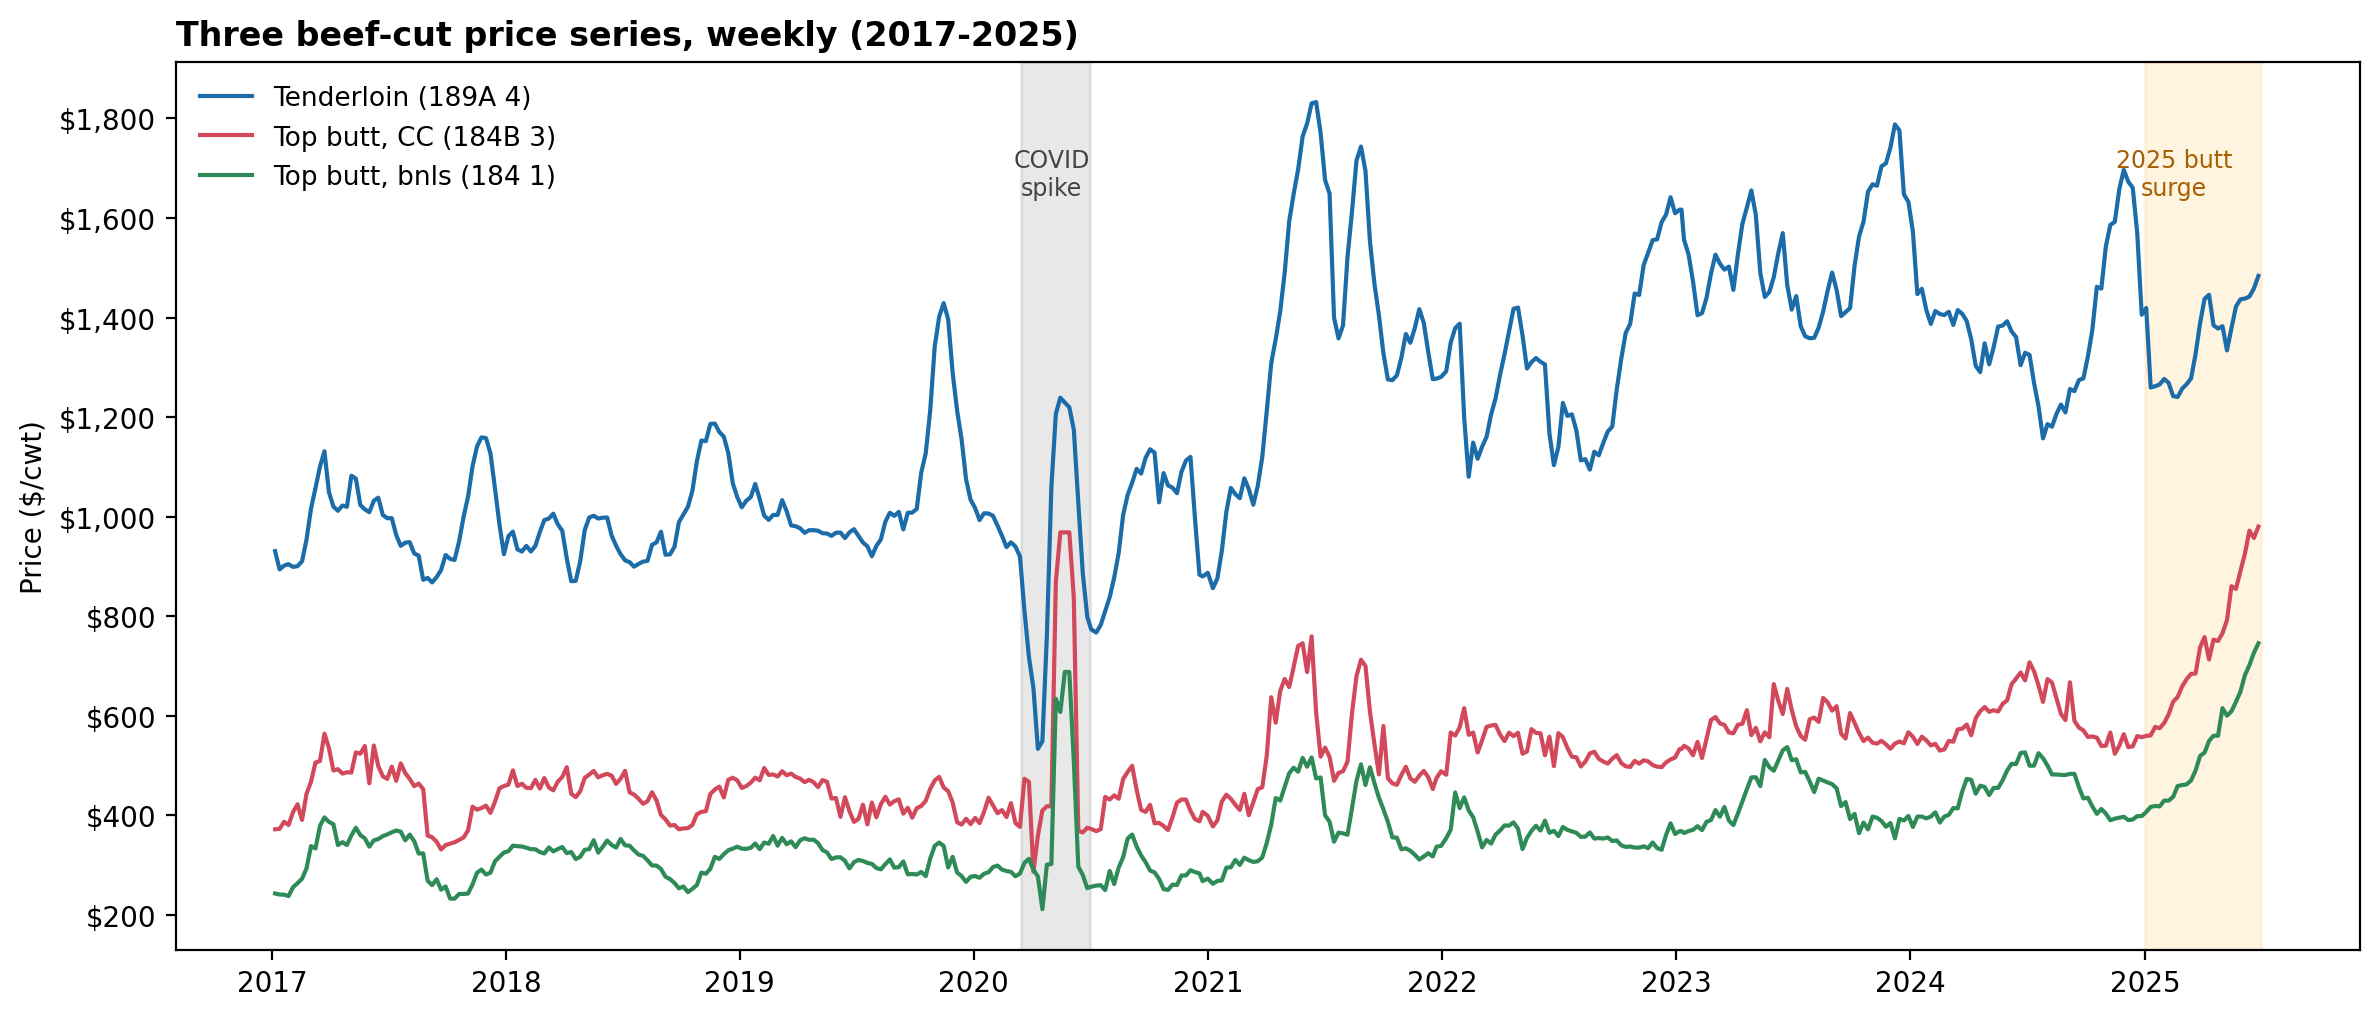

In [7]:
fig, ax = plt.subplots(figsize=(12, 5.2))
ax.plot(df.report_date, df.tndrloin_price,  color=C['tndrloin'],  lw=1.5, label='Tenderloin (189A 4)')
ax.plot(df.report_date, df.butt_CC_price,    color=C['butt_CC'],   lw=1.5, label='Top butt, CC (184B 3)')
ax.plot(df.report_date, df.butt_bnls_price,  color=C['butt_bnls'], lw=1.5, label='Top butt, bnls (184 1)')
ax.axvspan(pd.Timestamp('2020-03-15'), pd.Timestamp('2020-07-01'), color='grey',   alpha=0.18)
ax.text(pd.Timestamp('2020-05-01'), 1740, 'COVID\nspike', ha='center', va='top', fontsize=8.5, color='#444')
ax.axvspan(pd.Timestamp('2025-01-01'), pd.Timestamp('2025-07-01'), color='orange', alpha=0.12)
ax.text(pd.Timestamp('2025-02-15'), 1740, '2025 butt\nsurge', ha='center', va='top', fontsize=8.5, color='#a85f00')
ax.yaxis.set_major_formatter(usd)
ax.xaxis.set_major_locator(mdates.YearLocator()); ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_title('Three beef-cut price series, weekly (2017-2025)', fontweight='bold', loc='left')
ax.set_ylabel('Price ($/cwt)'); ax.legend(frameon=False, fontsize=9.5)
plt.tight_layout(); save_plot("A2_price_series"); plt.show()

**Figure 1 — the three price series.** Tenderloin trades at roughly two to three times the price of the butt cuts. Three features stand out: the spring-2020 COVID spike, the 2025 butt-cut surge, and a step up to a higher overall level from about 2021 on.

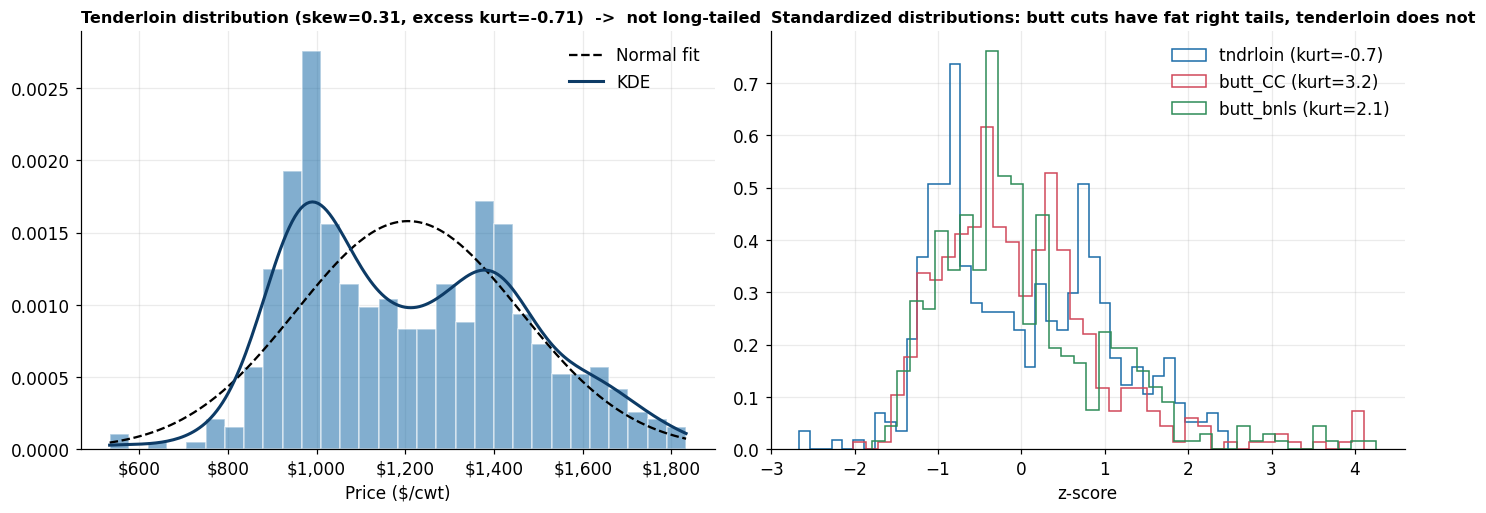

In [8]:
t = df.tndrloin_price
fig, axs = plt.subplots(1, 2, figsize=(13, 4.8))
axs[0].hist(t, bins=30, color=C['tndrloin'], alpha=0.55, density=True, edgecolor='white')
xs = np.linspace(t.min(), t.max(), 200)
axs[0].plot(xs, sps.norm.pdf(xs, t.mean(), t.std()), 'k--', lw=1.5, label='Normal fit')
axs[0].plot(xs, sps.gaussian_kde(t)(xs), color='#0d3b66', lw=2, label='KDE')
axs[0].set_title(f'Tenderloin distribution (skew={t.skew():.2f}, excess kurt={t.kurtosis():.2f})  ->  not long-tailed',
                 fontweight='bold', fontsize=10.5, loc='left')
axs[0].set_xlabel('Price ($/cwt)'); axs[0].xaxis.set_major_formatter(usd); axs[0].legend(frameon=False)
for k, col in [('tndrloin_price','tndrloin'), ('butt_CC_price','butt_CC'), ('butt_bnls_price','butt_bnls')]:
    z = (df[k] - df[k].mean()) / df[k].std()
    axs[1].hist(z, bins=40, histtype='step', lw=2, color=C[col], density=True,
                label=f"{col} (kurt={df[k].kurtosis():.1f})")
axs[1].set_title('Standardized distributions: butt cuts have fat right tails, tenderloin does not',
                 fontweight='bold', fontsize=10.5, loc='left')
axs[1].set_xlabel('z-score'); axs[1].legend(frameon=False)
plt.tight_layout(); save_plot("A2_distributions"); plt.show()


**Figure 2 — distribution and tail contrast.** Tenderloin is mildly right-skewed but *platykurtic* (negative excess kurtosis) and visibly bimodal — a level shift, not a fat tail. The two butt cuts, in contrast, carry genuinely heavy right tails.

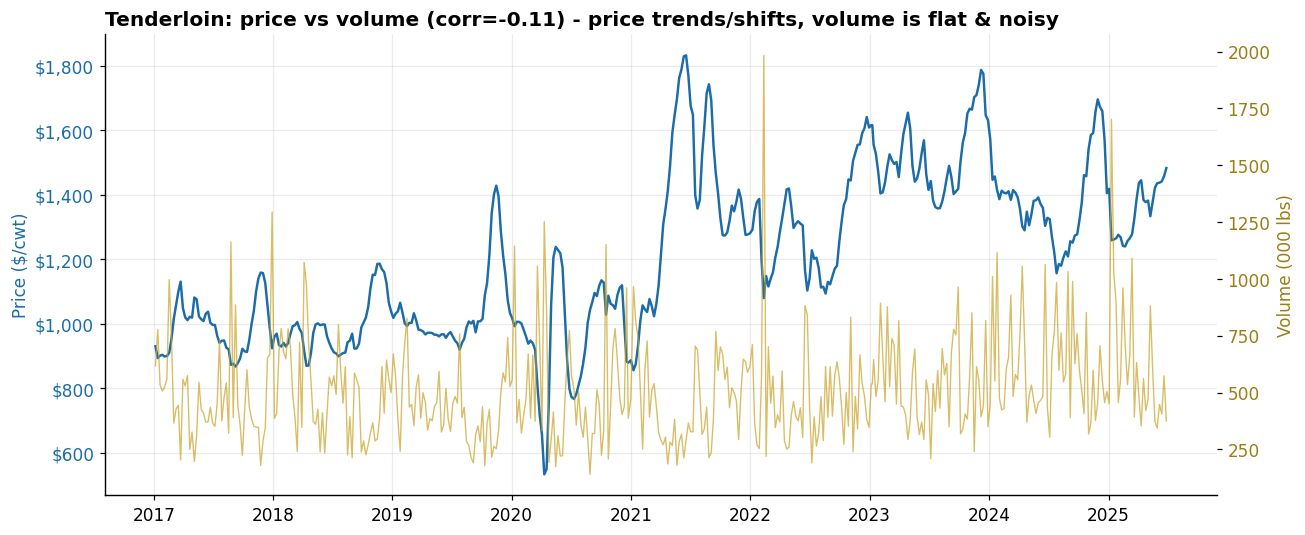

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df.report_date, df.tndrloin_price, color=C['tndrloin'], lw=1.6)
ax.set_ylabel('Price ($/cwt)', color=C['tndrloin']); ax.yaxis.set_major_formatter(usd)
ax.tick_params(axis='y', labelcolor=C['tndrloin'])
ax2 = ax.twinx(); ax2.grid(False)
ax2.plot(df.report_date, df.tndrloin_volume / 1e3, color='#c9a227', lw=0.9, alpha=0.7)
ax2.set_ylabel('Volume (000 lbs)', color='#9c7d14'); ax2.tick_params(axis='y', labelcolor='#9c7d14')
ax.xaxis.set_major_locator(mdates.YearLocator()); ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
r = df.tndrloin_price.corr(df.tndrloin_volume)
ax.set_title(f'Tenderloin: price vs volume (corr={r:.2f}) - price trends/shifts, volume is flat & noisy',
             fontweight='bold', loc='left')
plt.tight_layout(); save_plot("A2_price_vs_volume"); plt.show()

**Figure 3 — price versus volume.** Price trends and shifts level over time, while volume stays flat, noisy, and mean-reverting, only weakly (and negatively) correlated with price.

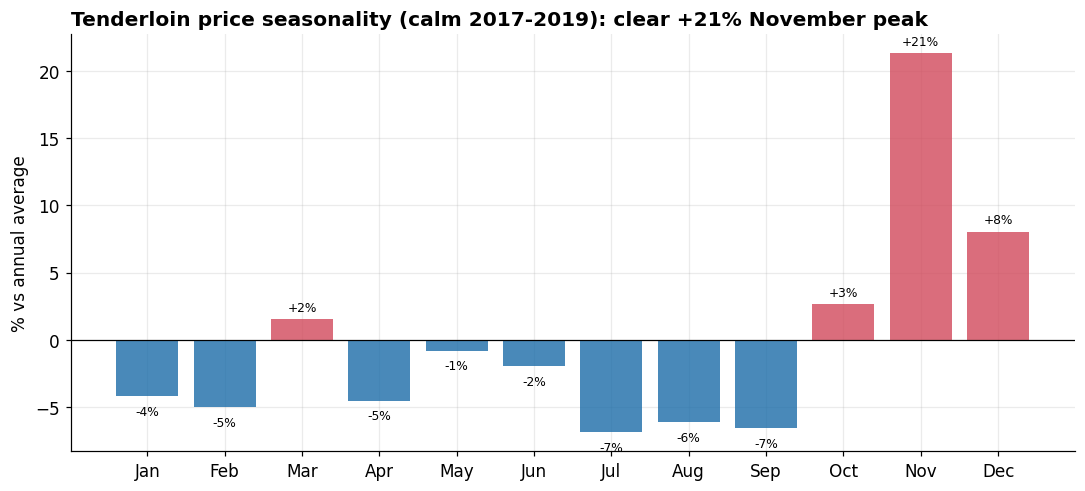

In [10]:
calm = df[df.year.isin([2017, 2018, 2019])].copy()
calm['t_norm'] = calm.groupby('year')['tndrloin_price'].transform(lambda s: s / s.mean())
seas = calm.groupby('month')['t_norm'].mean() * 100 - 100
fig, ax = plt.subplots(figsize=(10, 4.6))
ax.bar(range(1, 13), seas.values, color=['#d1495b' if v > 0 else '#1b6ca8' for v in seas], alpha=0.8)
ax.axhline(0, color='k', lw=0.8)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_ylabel('% vs annual average')
ax.set_title('Tenderloin price seasonality (calm 2017-2019): clear +21% November peak',
             fontweight='bold', loc='left')
for i, v in zip(range(1, 13), seas.values):
    ax.text(i, v + (0.6 if v >= 0 else -1.4), f'{v:+.0f}%', ha='center', fontsize=8)
plt.tight_layout(); save_plot("A2_seasonality"); plt.show()

**Figure 4 — seasonality across the calm years (2017–2019).** A clear **+21% November peak** and a summer trough, consistent with holiday demand for premium loin.

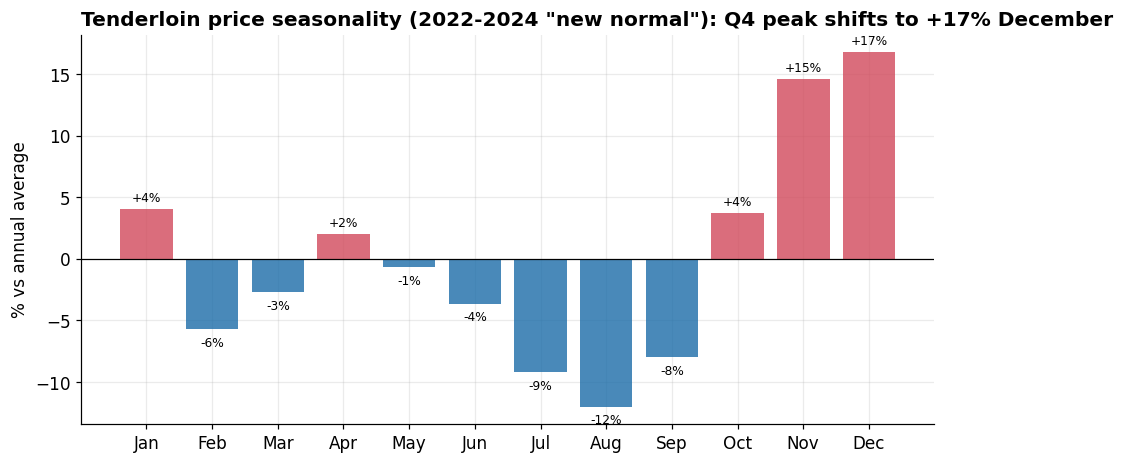

In [11]:
calm = df[df.year.isin([2022,2023,2024])].copy()
calm['t_norm'] = calm.groupby('year')['tndrloin_price'].transform(lambda s: s / s.mean())
seas = calm.groupby('month')['t_norm'].mean() * 100 - 100
fig, ax = plt.subplots(figsize=(10, 4.6))
ax.bar(range(1, 13), seas.values, color=['#d1495b' if v > 0 else '#1b6ca8' for v in seas], alpha=0.8)
ax.axhline(0, color='k', lw=0.8)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_ylabel('% vs annual average')
ax.set_title('Tenderloin price seasonality (2022-2024 "new normal"): Q4 peak shifts to +17% December',
             fontweight='bold', loc='left')
for i, v in zip(range(1, 13), seas.values):
    ax.text(i, v + (0.6 if v >= 0 else -1.4), f'{v:+.0f}%', ha='center', fontsize=8)

Answers to the A.2 questions:

- Extreme periods? Yes. The spring-2020 COVID spike and the 2025 butt-cut surge, with all three series stepping up to a higher level from about 2021. See Fig 1.
- Seasonality outside those periods? Yes. A clear +21% November peak in the calm years. See Fig 4.
- Tenderloin long tails? No. Mildly right-skewed but platykurtic and bimodal, a level shift rather than fat tails. The two butt cuts do carry fat right tails. See Fig 2.
- Price versus volume? Weakly inverse, about -0.1 overall and -0.4 in the calm years. Price carries forecastable structure, volume reads as stationary noise. See Fig 3.

## A.3 Extreme values

Because the price level shifted, a z-score on the level would flag the whole post-2021 era as high. Screening weekly percent changes against their own standard deviation instead pinpoints abnormal events.

In [12]:
desc = df[price_cols].describe(percentiles=[.01, .05, .5, .95, .99]).T
desc['skew']        = df[price_cols].skew()
desc['excess_kurt'] = df[price_cols].kurtosis()
desc.round(1)

,count,mean,std,min,1%,5%,50%,95%,99%,max,skew,excess_kurt
tndrloin_price,444.0,1206.0,252.5,533.3,763.5,883.8,1170.5,1652.2,1773.7,1832.9,0.3,-0.7
butt_CC_price,444.0,515.3,112.9,286.7,346.1,374.1,496.8,711.6,963.4,980.1,1.4,3.2
butt_bnls_price,444.0,369.5,88.4,211.2,240.5,258.8,350.8,518.7,685.0,745.4,1.2,2.1


In [13]:
ret = df[price_cols].pct_change() * 100
print("Weekly %-change std (volatility) per cut:")
print(ret.std().round(1).to_string())

flags = (ret.abs() > 3 * ret.std()).any(axis=1)
by_year = df.loc[flags, 'report_date'].dt.year.value_counts().sort_index()
print(f"\n>3-sigma-move weeks: {int(flags.sum())}   by year: {by_year.to_dict()}")

print("\nLargest single-week tenderloin moves:")
big = ret['tndrloin_price'].abs().sort_values(ascending=False).head(6).index
print(df.loc[big, ['report_date']]
      .assign(pct_change=ret.loc[big, 'tndrloin_price'].round(1))
      .to_string(index=False))

Weekly %-change std (volatility) per cut:
tndrloin_price     4.7
butt_CC_price      8.4
butt_bnls_price    7.8

>3-sigma-move weeks: 10   by year: {2020: 9, 2021: 1}

Largest single-week tenderloin moves:
report_date  pct_change
 2020-05-01        39.2
 2020-04-24        38.6
 2020-04-10       -18.7
 2021-07-16       -15.1
 2020-05-08        13.9
 2020-06-19       -13.8


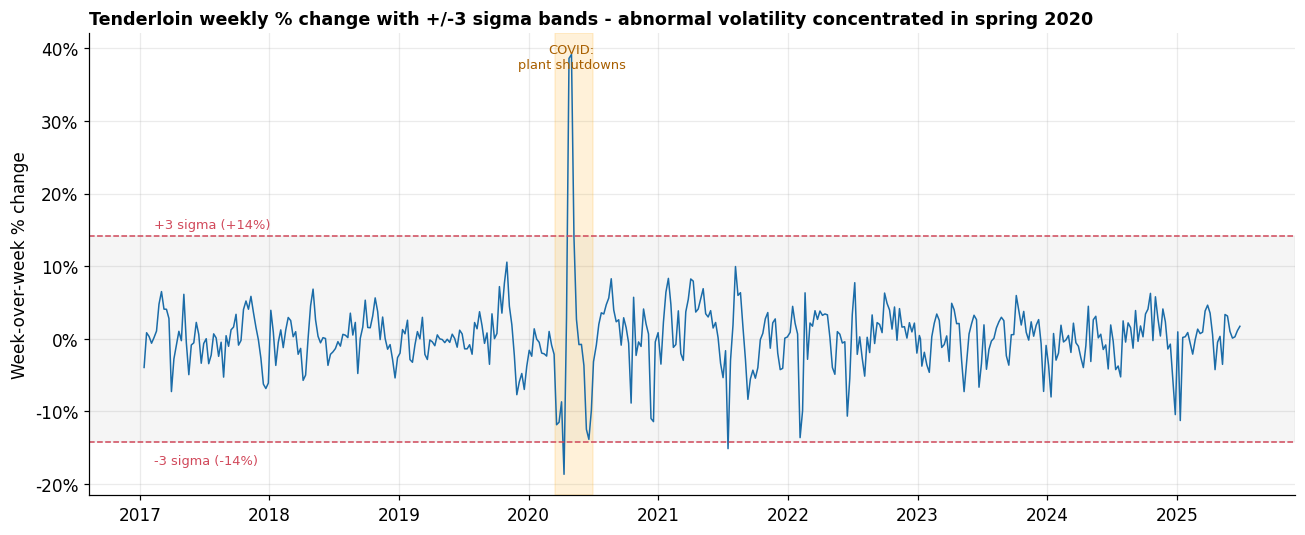

In [14]:
sd = ret['tndrloin_price'].std()
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df.report_date, ret['tndrloin_price'], color=C['tndrloin'], lw=1.0)
ax.axhline(3 * sd, color='#d1495b', ls='--', lw=1); ax.axhline(-3 * sd, color='#d1495b', ls='--', lw=1)
ax.axhspan(-3 * sd, 3 * sd, color='grey', alpha=0.08)
ax.text(df.report_date.iloc[5],  3 * sd + 1,  f'+3 sigma (+{3*sd:.0f}%)', color='#d1495b', fontsize=8.5)
ax.text(df.report_date.iloc[5], -3 * sd - 3,  f'-3 sigma ({-3*sd:.0f}%)', color='#d1495b', fontsize=8.5)
ax.axvspan(pd.Timestamp('2020-03-15'), pd.Timestamp('2020-07-01'), color='orange', alpha=0.15)
ax.text(pd.Timestamp('2020-05-01'), ret['tndrloin_price'].max() * 0.95,
        'COVID:\nplant shutdowns', ha='center', fontsize=8.5, color='#a85f00')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.xaxis.set_major_locator(mdates.YearLocator()); ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_title('Tenderloin weekly % change with +/-3 sigma bands - abnormal volatility concentrated in spring 2020',
             fontweight='bold', fontsize=11.5, loc='left')
ax.set_ylabel('Week-over-week % change')
plt.tight_layout(); save_plot("A3_volatility_bands"); plt.show()


**Figure 5 — tenderloin weekly percent change**, with bands at ±3 standard deviations.

Finding: about 10 weeks show a move beyond three standard deviations, most of them in spring 2020 during the COVID plant shutdowns. Tenderloin swung +39%, +39%, -19%, +14% in consecutive weeks. The rest of the series sits inside the bands. The descriptive stats also pin the tenderloin all-time high near \$1,833 in June 2021 and the 2025 record highs in the butt cuts.

Result: a forward-filled, gap-free panel of 444 weeks from 2017 to 2025, held in memory. Part B reproduces this same clean panel from beef_data.csv.